In [3]:
from scripts.helpers import  ser_tpye,  get_ser_sequence, penta_matrix, diversity, aa_order, DiversityAnalysis
from scripts.helpers import diversity as divrs
import pandas as pd
import numpy as np
import math
import os 

In [4]:
required_folders = ["input", "output"]
for folder in required_folders:
    if os.path.exists(folder) is False:
        os.mkdir(folder)
        print(f"{folder} was created.")

input was created.
output was created.


In [2]:
# importing datasets to python
path_input = "input"
path_output = "output"

files_input = os.listdir(path_input)
files_list = []

name_csv_dic = {'covid_vaccine_new.mut_df.csv':"mut_df",
                'new_covid_median.csv':"median",
                'covid_vaccine_new.sequences.csv':"seqs"}
                
for i in files_input:
    name = i.split(".csv")[0]
    files_list.append(name)
    globals()[name_csv_dic[i]] = pd.read_csv(path_input+"\\"+i, index_col=0)

# converting pos_aa type to int from float
# Converting ab_target values to more easier format
mut_df["pos_aa"] = mut_df["pos_aa"].astype("int")
mut_df["ab_target"] = mut_df["ab_target"].replace({'Non-Spike B':"sn", 'Spike+ Mem B':"sp"})

In [3]:
# Creating filters 
cond_func = mut_df["functional"] == 1
cond_posaa =  mut_df["pos_aa"].isin(range(1,105))
cond_sid = mut_df["sample_id"].notnull()
cond_syn = mut_df["syn"] == 0 
cond_nonstop = mut_df["to_aas"] != "*"
cond_cnt = mut_df["unique_cnt"] > 1

# filterd dataframe
filt_df = mut_df[cond_func & cond_sid  & cond_nonstop & cond_posaa & cond_cnt & cond_syn]

# correcting serine codon assosiation
for aa_t in ["from_aa", "to_aas"]:
    filt_df.loc[(filt_df[aa_t] == "S"),aa_t] = filt_df[(filt_df[aa_t] == "S")].apply(ser_tpye, target=aa_t, axis=1)
    #filt_df.loc[(filt_df[aa_t]=="S*"),aa_t] = filt_df.loc[(filt_df[aa_t]=="S*"),["clone_id","pos_aa"]].apply(get_ser_sequence, seq_df=seqs[["clone_id","sequence"]], axis=1)
    filt_df = filt_df[(filt_df[aa_t] != "S*")]

In [4]:
# pre 60% filtring
#head_10 = [104,  98,  41,  43,  86,  83,  38,  81, 102,  89,  44,  75,  46, 94,  37,  51,  79,  40]
#tail_10 = [64, 59, 58, 92, 90, 87, 65, 62, 66, 95, 57, 69, 35, 45, 68, 85, 55, 54]

head_10 = [ 98,  86,  41,  83,  38,  81, 102,  75,  89,  44,  46,  37,  40, 51,  79,  94,  39,  48]
tail_10 = [ 64,  59,  58,  90,  92,  65,  87, 101,  62,  74,  95,  66,  57, 69,  55,  45,  68,  85]

g:\My Drive\[M.Sc] Bioinformatic - Human Biology\Thesis\3. Thesis\4. Position Anlaysis\scripts\helpers.py:240: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.25, wspace=0.2)


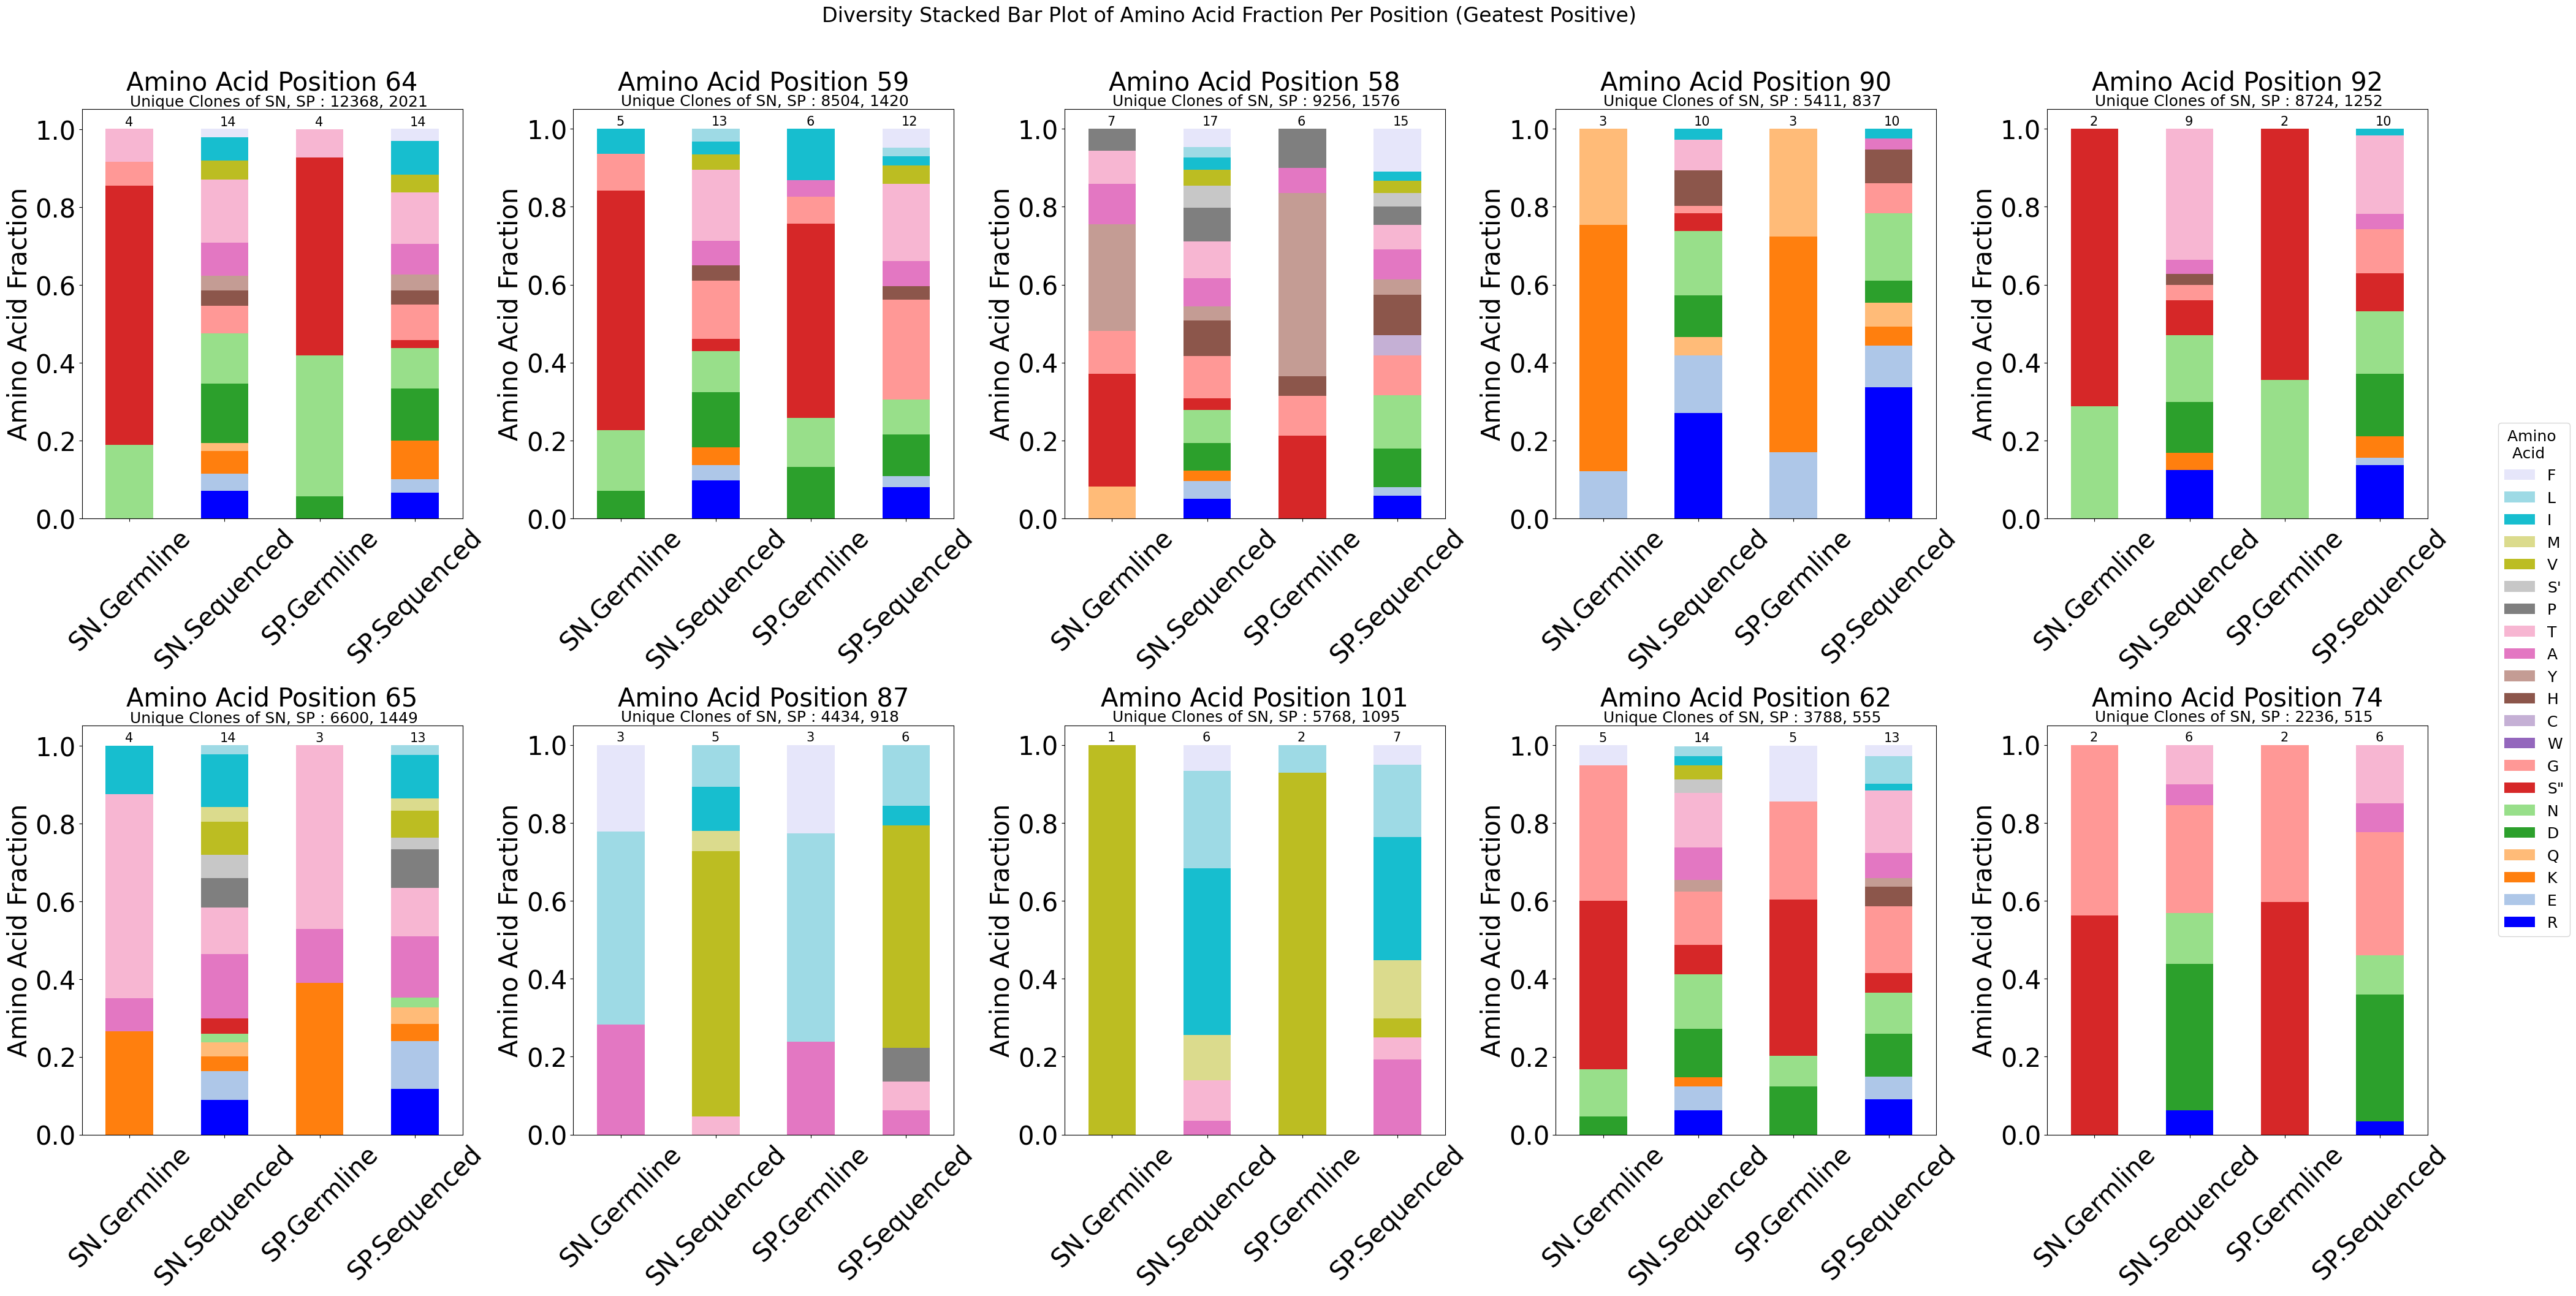

In [5]:
if True:
    from scripts.helpers import  analysis_information ,bar_freqs
    input_frq, input_mtr, input_cl = analysis_information(filt_df, name_metric="div", split_by="ab_target")
    
    bar_freqs(input_freqs=input_frq, input_metric=input_mtr, nclones_df=input_cl, name_metric="div", title="Geatest Positive", pos_plot=tail_10[0:10], save_fig=False, change_xticks=True)


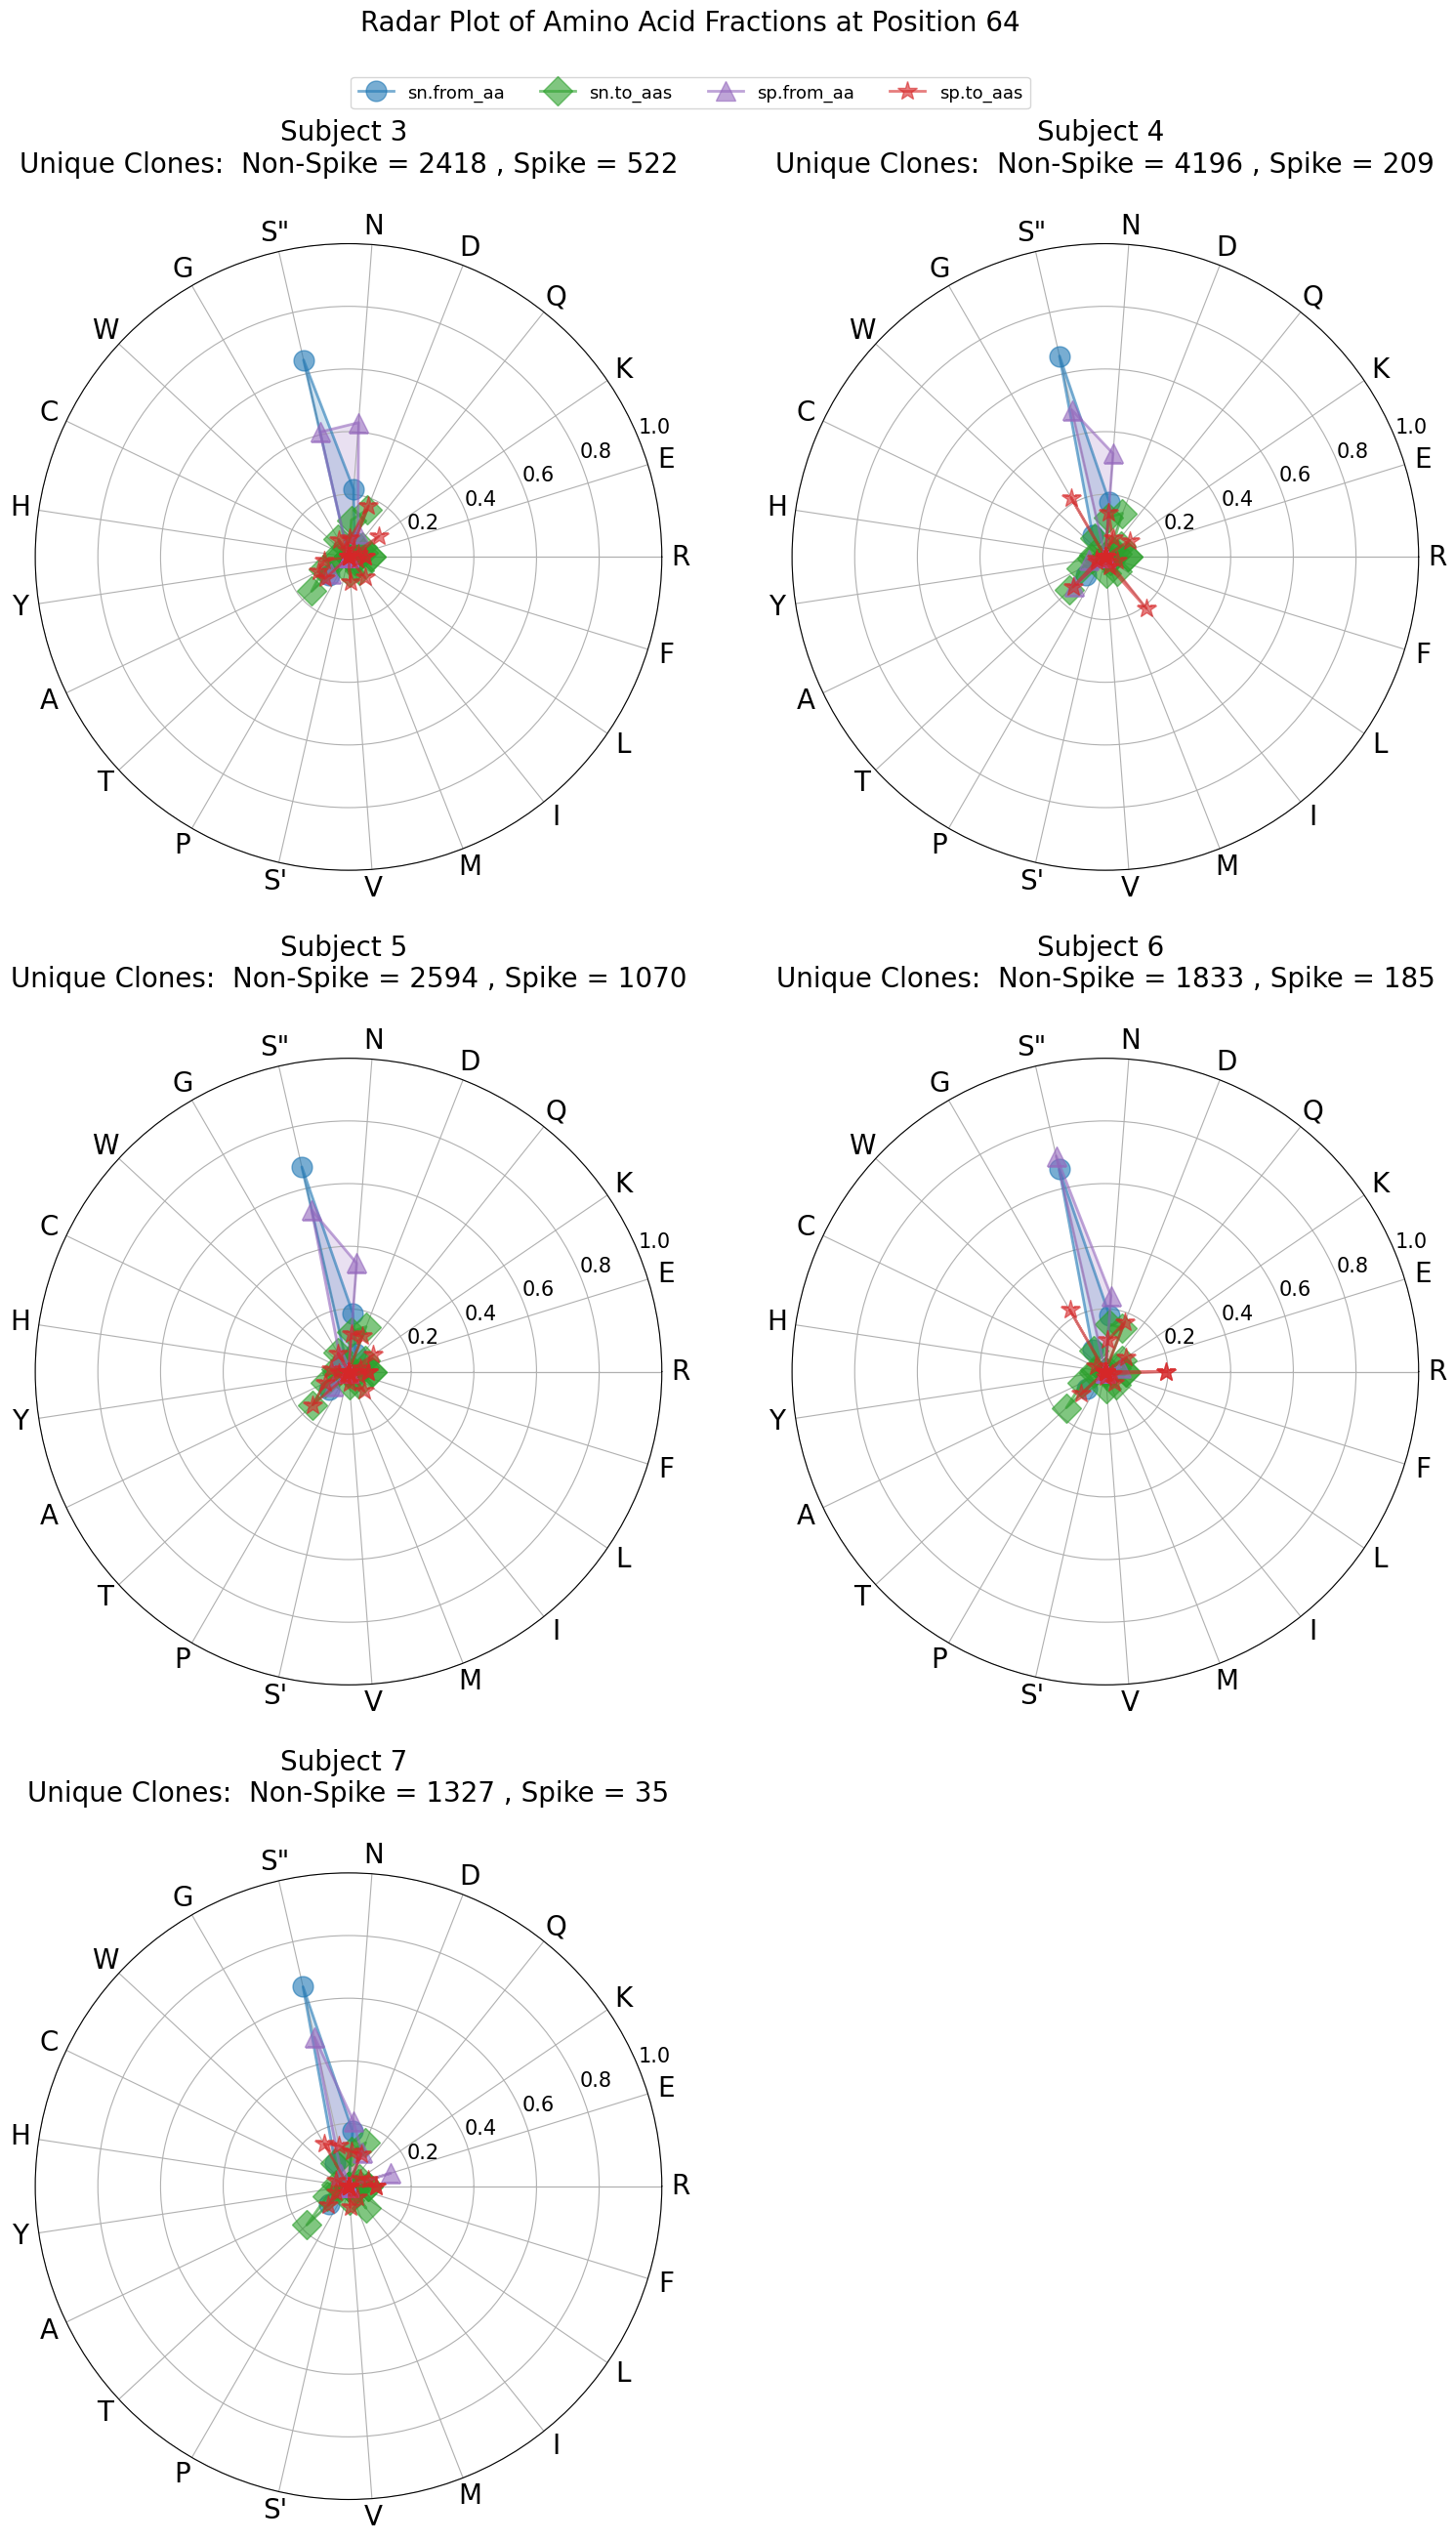

In [6]:
test = DiversityAnalysis(input_df=filt_df, split_by="ab_target", name_metric="div", split_subjects=True)

# radat plots
if True:
    test.plot_radar(pos_aa=64, save_figure=False)

In [7]:
wil_results, wil_raw = DiversityAnalysis(input_df=filt_df, split_by="ab_target", name_metric="div", split_subjects=True).do_wilcoxon(pos_aa=head_10)
wil_results

,subject,wilcoxon_w,p_value,n,dof
0,3,141.0,0.001075,18,16
1,4,105.0,0.000471,18,16
2,5,110.5,0.001934,18,16
3,6,128.0,0.000920,18,16
4,7,120.0,0.000314,18,16


In [8]:
#div_results = DiversityAnalysis(input_df=filt_df, split_by="ab_target", name_metric="div", split_subjects=True)

In [9]:
codon_dic_updated = {
                    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
                    'TCT': "S'", 'TCC': "S'", 'TCA': "S'", 'TCG': "S'",
                    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',  # * for STOP
                    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',

                    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
                    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
                    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
                    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',

                    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
                    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
                    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
                    'AGT': 'S"', 'AGC': 'S"', 'AGA': 'R', 'AGG': 'R',

                    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
                    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
                    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
                    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
                    }

def nt_transalte_104(nt_seq):
    import numpy as np
    translated = []
    for i in range(1,105):
        codon = nt_seq[i*3-3:i*3]
      
        if codon in list(codon_dic_updated.keys()):
            aa = codon_dic_updated[codon]  
        else:
            aa = np.nan
            
        translated.append(aa)
    return translated


def diversity(df):
    
    df_grouped = df.groupby("clone_id").agg({"germline":"unique"})
    df_grouped.reset_index(inplace=True)
    df_grouped["germline"]=df_grouped["germline"].apply(lambda x: x[0])
    df_grouped.rename({"germline":"germline_nt"},axis=1,inplace=True)
    df_grouped["germline_aa"] = df_grouped["germline_nt"].apply(nt_transalte_104)
    aas_list = df_grouped["germline_aa"].to_list()
    df_aas = pd.DataFrame(aas_list,columns=range(1,105))
    #df_aas.dropna(inplace=True)
    
    # for each position need:
    # 1. richness
    # 2. frequencies per aa
    # 3. diversity calculation
    
    div_list = []
    aa_range = list(range(1,105))
    
    import numpy as np
    temp_df = pd.DataFrame(0, index=np.arange(104), columns=["pos_aa","richness","diversity"])
    temp_df["pos_aa"] = aa_range
    
    for i in aa_range:
        aa_temp = df_aas.loc[:,i][df_aas.loc[:,i].notnull()]
        richness = len(aa_temp.unique())

        if richness == 0:         
            richness = 0
            diversity = 0
        
        else:
            freq = aa_temp.value_counts()/aa_temp.value_counts().sum()
            freq_table = freq.reset_index(name="freq").rename({"index":"aa"},axis=1)
            freq_table.index = freq_table.index + 1
            
            frequencies = freq_table["freq"].values
            
            import math
            t = 0
            
            for k in frequencies:
                
                Pi = k * math.log(k, math.e)
                t += Pi
            
            diversity = round(math.exp(-t))

        temp_df.loc[temp_df["pos_aa"]==i,["richness","diversity"]] = [richness,diversity]
    
    return temp_df

def getdiv(input_df:pd.DataFrame) -> int:
    return round(divrs(input_df.value_counts()/input_df.value_counts().sum()))

In [10]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

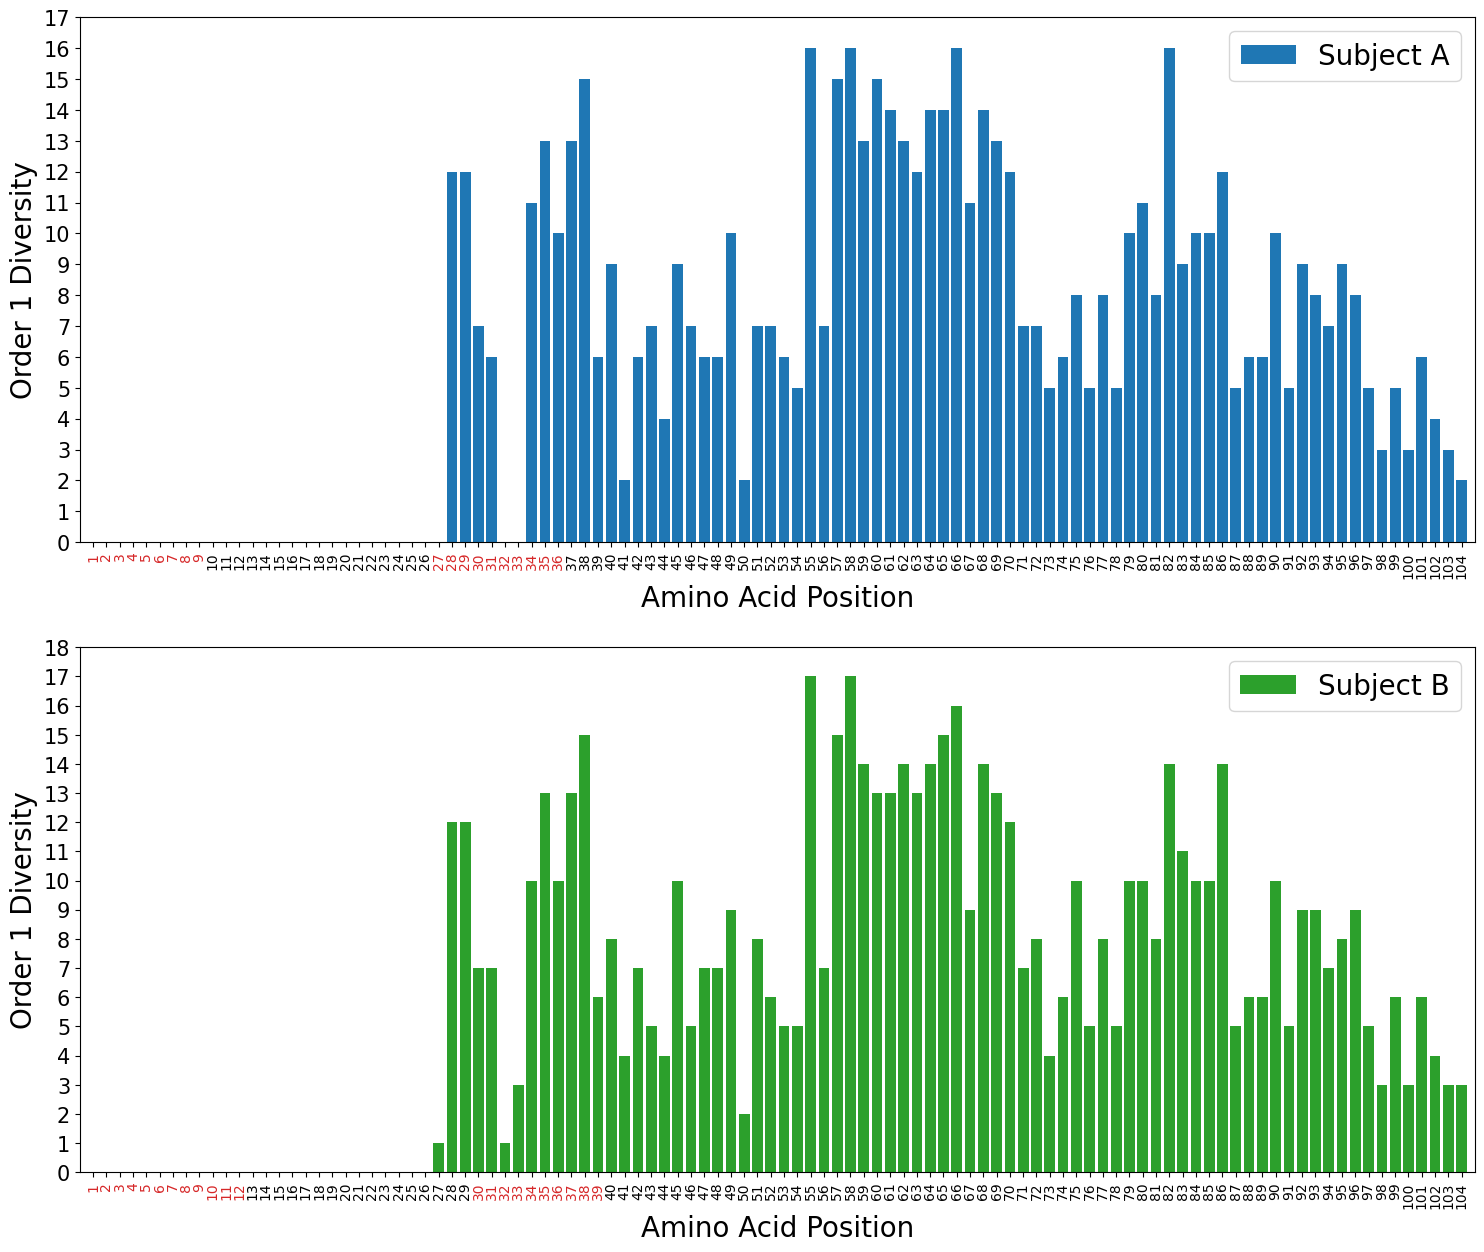

In [11]:
get_div = "to_aas"

if get_div == "to_aas":
    div_series = []
    for key in filt_df.subject_id.unique():
        subject = f"subject_{key}"
        cond = (filt_df.subject_id == key)
        div_subj = filt_df[cond].groupby("pos_aa").agg({"to_aas":getdiv}).reset_index()
        div_subj.rename({"to_aas":subject}, axis=1,inplace=True)
        div_series.append(div_subj)

if get_div == "germline":
    x_new = pd.DataFrame({"pos_aa":range(1,105), "subject_3":x})
    y_new = pd.DataFrame({"pos_aa":range(1,105), "subject_4":y})
    div_series = [x_new, y_new]

fig, ax = plt.subplots(2,1, figsize=(18,15))

for divsr,axs,cr, newlabel in zip(div_series[0:2], ax, ["tab:blue","tab:green"], ["Subject A", "Subject B"]):
    label_subj = divsr.columns[-1]
    axs.bar(x=divsr.pos_aa, height=divsr[label_subj], label=newlabel, color=cr)
    axs.set_xlabel("Amino Acid Position")
    axs.set_ylabel("Order 1 Diversity")
    x_range = np.arange(1,105,1)
    axs.set_xticks(x_range)
    axs.tick_params(axis="y", labelsize=15)
    axs.tick_params(axis='x', labelrotation=90, labelsize=10)
    axs.set_xlim(x_range[0]-1,x_range[-1]+1)
    axs.set_yticks(np.arange(0,divsr[label_subj].max()+2,1))
    axs.set_ylim(0,divsr[label_subj].max()+1)
    axs.legend()

    range_cdr = list(range(27,39)) + list(range(56,66)) #CDR1, CDR2
    for xtick, xcolor in zip(axs.get_xticklabels(), ["tab:red" if i in range_cdr else "black" for i in divsr.pos_aa.astype("int")]):
        xtick.set_color(xcolor)

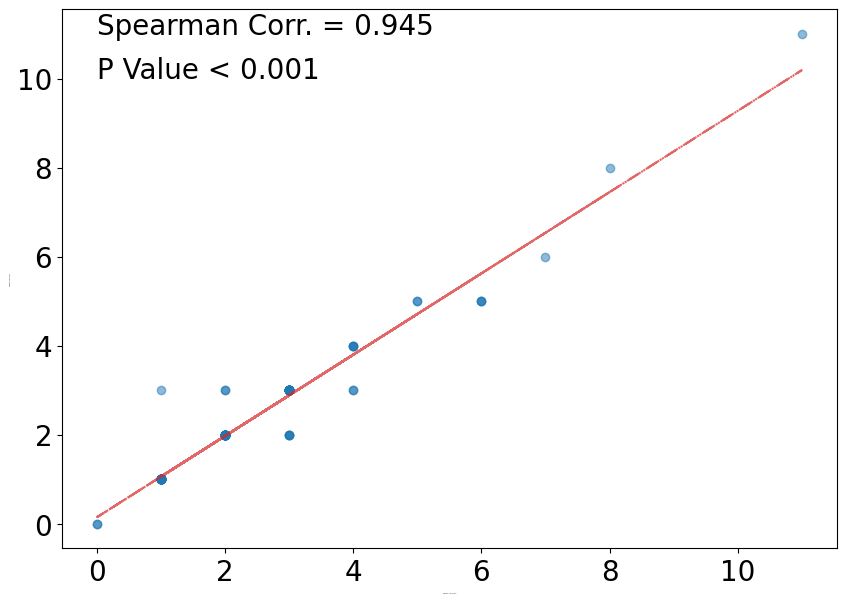

In [ ]:
subjects_ab = pd.DataFrame(index=range(28,105))
plt.figure(figsize=(10, 7))

for i in div_series[0:2]:
    subjects_ab = pd.concat([subjects_ab,i.set_index("pos_aa")], axis=1).fillna(0).astype("int")

x = diversity(filt_df[filt_df.subject_id == 3]).diversity
y = diversity(filt_df[filt_df.subject_id == 4]).diversity

plt.scatter(x=x, y=y, alpha=0.5)
plt.xlabel("Subject A Diversity", size=1)
plt.ylabel("Subject B Diversity", size=1)

spearman = spearmanr(x,y)
spearman_r = round(spearman[0],3)
spearman_pval = round(spearman[1],3)

plt.text(x=0, y=11, s=f"Spearman Corr. = {spearman_r}")
plt.text(x=0, y=10, s=f"P Value < 0.001")

coef = np.polyfit(x, y, 1)
lm = np.poly1d(coef)
plt.plot(x, lm(x), label='Linear Fit', color="tab:red", alpha=0.7, ls="-.")